In [1]:
"""
Clasificador restringido — VERSIÓN LIGERA (solo regresión logística)
--------------------------------------------------------------------------
Misma lógica y pipeline del notebook original (5_clasificador_restringido),
con un solo cambio: en vez de comparar 5 modelos (Random Forest, red
neuronal, etc.) y quedarnos con el de mejor test_f1, entrenamos ÚNICAMENTE
regresión logística — evita el tiempo de entrenar los modelos que no vamos
a usar, y genera un .joblib final mucho más ligero. Ya que al momento de 
intertar integrarlo en el proyecto GIT, era muy pesado para subirse.

Justificación con datos reales del notebook original: la logística pierde
solo ~0.003 de test_f1 frente al "mejor" modelo (Random Forest en F, red
neuronal en M), y tiene CERO brecha train-cv (mejor generalización que
Random Forest, que mostraba sobreajuste de 0.106 en F).

AVISO IMPORTANTE: los reconstructores de fuerza de agarre y VO2max (sección
5) también se guardan dentro del .joblib final. Se redujeron de 200 a 50
árboles (y de profundidad 10 a 6) para aligerar el archivo — esto sacrifica
algo de precisión.

Estructura (idéntica al notebook original, solo cambia la sección 7):
1. Carga del dataset ya etiquetado (nivel_cluster)
2. Definición de variables restringidas (auto-medibles)
3. Feature engineering básico (derivadas simples, sin necesidad de modelos)
4. Reconstrucción de % grasa corporal (fórmula de Deurenberg — real, publicada)
5. Reconstrucción de fuerza de agarre y VO2max (RandomForestRegressor auxiliar)
6. Split train/test estratificado, por género
7. Modelo — SOLO regresión logística (versión ligera)
8. Entrenamiento con tuning + evaluación train / cross-validation / test
9. Tabla comparativa final
10. Guardado del modelo por género
11-12. Matrices de confusión
"""

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 3

In [28]:
# ---------------------------------------------------------------------------
# 1. CARGA DEL DATASET YA ETIQUETADO
# ---------------------------------------------------------------------------
df = pd.read_parquet("../Data/processed/fitness_measurements_adult_clustered.parquet")
print(f"Dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print("\nDistribución de nivel_cluster por género:")
print(df.groupby("gender_code")["nivel_cluster"].value_counts(normalize=True).round(3))

Dataset: 430666 filas, 28 columnas

Distribución de nivel_cluster por género:
gender_code  nivel_cluster
F            0                0.347
             2                0.344
             1                0.309
M            0                0.392
             1                0.309
             2                0.300
Name: proportion, dtype: float64


/tmp/ipykernel_46889/1798800265.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("gender_code")["nivel_cluster"].value_counts(normalize=True).round(3))


In [29]:
# ---------------------------------------------------------------------------
# 2. VARIABLES RESTRINGIDAS (auto-medibles, sin equipo de laboratorio)
# ---------------------------------------------------------------------------
RESTRICTED_BASE = [
    "age", "height_cm", "weight_kg", "waist_circumference_cm",
    "sit_and_reach_cm", "cross_situp_count", "standing_long_jump_cm",
    "reaction_time_sec",
]
LAB_ONLY = ["grip_strength_avg_kg", "vo2max_estimate", "body_fat_pct"]

print("Variables restringidas (input real en producción):", RESTRICTED_BASE)
print("Variables de laboratorio (solo para entrenar reconstructores):", LAB_ONLY)

Variables restringidas (input real en producción): ['age', 'height_cm', 'weight_kg', 'waist_circumference_cm', 'sit_and_reach_cm', 'cross_situp_count', 'standing_long_jump_cm', 'reaction_time_sec']
Variables de laboratorio (solo para entrenar reconstructores): ['grip_strength_avg_kg', 'vo2max_estimate', 'body_fat_pct']


In [30]:
# ---------------------------------------------------------------------------
# 3. FEATURE ENGINEERING BÁSICO — derivadas que NO requieren modelos extra
# ---------------------------------------------------------------------------
df["bmi_calc"] = df["weight_kg"] / (df["height_cm"] / 100) ** 2
df["waist_to_height_ratio"] = df["waist_circumference_cm"] / df["height_cm"]
df["relative_power"] = df["standing_long_jump_cm"] / df["weight_kg"]
df["situps_por_edad"] = df["cross_situp_count"] / df["age"]
df["salto_por_altura"] = df["standing_long_jump_cm"] / df["height_cm"]
df["edad_x_imc"] = df["age"] * df["bmi_calc"]

DERIVED_SIMPLE = [
    "bmi_calc", "waist_to_height_ratio", "relative_power",
    "situps_por_edad", "salto_por_altura", "edad_x_imc",
]
print("Variables derivadas simples agregadas:", DERIVED_SIMPLE)

Variables derivadas simples agregadas: ['bmi_calc', 'waist_to_height_ratio', 'relative_power', 'situps_por_edad', 'salto_por_altura', 'edad_x_imc']


In [31]:
# ---------------------------------------------------------------------------
# 4. RECONSTRUCCIÓN DE % GRASA CORPORAL — fórmula de Deurenberg (real, publicada)
# ---------------------------------------------------------------------------
df["sexo_num"] = (df["gender_code"] == "M").astype(int)
df["body_fat_pct_estimado"] = (
    1.20 * df["bmi_calc"] + 0.23 * df["age"] - 10.8 * df["sexo_num"] - 5.4
)
print("Body fat % estimado (Deurenberg) agregado.")
print(df[["gender_code", "body_fat_pct", "body_fat_pct_estimado"]].sample(5, random_state=1))

Body fat % estimado (Deurenberg) agregado.
       gender_code  body_fat_pct  body_fat_pct_estimado
267726           F     36.799999              39.107599
81276            M     24.100000              17.715556
50369            M     17.100000              20.566310
301554           F     20.500000              30.101636
248932           M     27.700001              25.705591


In [ ]:
# ---------------------------------------------------------------------------
# 5. RECONSTRUCCIÓN DE FUERZA DE AGARRE Y VO2MAX — modelos auxiliares
# ---------------------------------------------------------------------------
# Reconstructores aligerados aún más: 15 árboles / profundidad 4 / mínimo
# 50 muestras por hoja (antes 50/6, y originalmente 200/10). 

FEATURES_FINALES = RESTRICTED_BASE + DERIVED_SIMPLE + [
    "body_fat_pct_estimado", "grip_strength_avg_kg_reconstruido", "vo2max_estimate_reconstruido",
]

resultados = {}

for genero in ["F", "M"]:
    print(f"\n{'='*60}\nGÉNERO: {genero}\n{'='*60}")

    sub = df[df["gender_code"] == genero].copy()

    train_idx, test_idx = train_test_split(
        sub.index, test_size=TEST_SIZE, random_state=RANDOM_STATE,
        stratify=sub["nivel_cluster"],
    )
    train_df = sub.loc[train_idx].copy()
    test_df = sub.loc[test_idx].copy()
    print(f"n total = {len(sub)}  |  train = {len(train_df)}  |  test = {len(test_df)}")

    predictores_reconstruccion = RESTRICTED_BASE + DERIVED_SIMPLE

    reconstructor_grip = RandomForestRegressor(
        n_estimators=15, max_depth=4, min_samples_leaf=50, random_state=RANDOM_STATE, n_jobs=-1,
    )
    reconstructor_grip.fit(train_df[predictores_reconstruccion], train_df["grip_strength_avg_kg"])

    reconstructor_vo2 = RandomForestRegressor(
        n_estimators=15, max_depth=4, min_samples_leaf=50, random_state=RANDOM_STATE, n_jobs=-1,
    )
    reconstructor_vo2.fit(train_df[predictores_reconstruccion], train_df["vo2max_estimate"])

    for split_df in (train_df, test_df):
        split_df["grip_strength_avg_kg_reconstruido"] = reconstructor_grip.predict(split_df[predictores_reconstruccion])
        split_df["vo2max_estimate_reconstruido"] = reconstructor_vo2.predict(split_df[predictores_reconstruccion])

    r2_grip = reconstructor_grip.score(test_df[predictores_reconstruccion], test_df["grip_strength_avg_kg"])
    r2_vo2 = reconstructor_vo2.score(test_df[predictores_reconstruccion], test_df["vo2max_estimate"])
    print(f"R² reconstrucción agarre (test): {r2_grip:.3f}  |  R² reconstrucción VO2max (test): {r2_vo2:.3f}")

    resultados[genero] = {
        "train_df": train_df, "test_df": test_df,
        "reconstructor_grip": reconstructor_grip, "reconstructor_vo2": reconstructor_vo2,
        "r2_grip": r2_grip, "r2_vo2": r2_vo2,
    }


GÉNERO: F


n total = 174387  |  train = 139509  |  test = 34878
R² reconstrucción agarre (test): 0.277  |  R² reconstrucción VO2max (test): 0.579

GÉNERO: M
n total = 256279  |  train = 205023  |  test = 51256
R² reconstrucción agarre (test): 0.306  |  R² reconstrucción VO2max (test): 0.602


In [33]:
# ---------------------------------------------------------------------------
# 6. PREPARAR X/y FINALES (ya con las variables reconstruidas)
# ---------------------------------------------------------------------------
for genero in ["F", "M"]:
    train_df = resultados[genero]["train_df"]
    test_df = resultados[genero]["test_df"]

    resultados[genero]["X_train"] = train_df[FEATURES_FINALES]
    resultados[genero]["y_train"] = train_df["nivel_cluster"]
    resultados[genero]["X_test"] = test_df[FEATURES_FINALES]
    resultados[genero]["y_test"] = test_df["nivel_cluster"]

print("Features finales del clasificador restringido:")
print(FEATURES_FINALES)

Features finales del clasificador restringido:
['age', 'height_cm', 'weight_kg', 'waist_circumference_cm', 'sit_and_reach_cm', 'cross_situp_count', 'standing_long_jump_cm', 'reaction_time_sec', 'bmi_calc', 'waist_to_height_ratio', 'relative_power', 'situps_por_edad', 'salto_por_altura', 'edad_x_imc', 'body_fat_pct_estimado', 'grip_strength_avg_kg_reconstruido', 'vo2max_estimate_reconstruido']


In [ ]:
# ---------------------------------------------------------------------------
# 7. MODELO — SOLO REGRESIÓN LOGÍSTICA (versión ligera)
# ---------------------------------------------------------------------------
# Se quitaron Random Forest, Histogram Gradient Boosting, KNN y la red neuronal
MODELOS = {
    "Regresión logística": {
        "estimator": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
        "param_distributions": {"clf__C": [0.01, 0.1, 1, 10]},
    },
}
print("Modelo a entrenar:", list(MODELOS.keys()))

Modelo a entrenar: ['Regresión logística']


In [35]:
# ---------------------------------------------------------------------------
# 8. ENTRENAMIENTO + EVALUACIÓN TRAIN / CROSS-VALIDATION / TEST
# ---------------------------------------------------------------------------
filas_comparacion = []
modelos_entrenados = {}

for genero in ["F", "M"]:
    X_train = resultados[genero]["X_train"]
    y_train = resultados[genero]["y_train"]
    X_test = resultados[genero]["X_test"]
    y_test = resultados[genero]["y_test"]

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    for nombre_modelo, config in MODELOS.items():
        print(f"\nEntrenando {nombre_modelo} — género {genero}...")

        search = RandomizedSearchCV(
            estimator=config["estimator"],
            param_distributions=config["param_distributions"],
            n_iter=4,  # el grid de logística solo tiene 4 combinaciones posibles
            scoring=["accuracy", "f1_macro"],
            refit="f1_macro",
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        search.fit(X_train, y_train)

        best_idx = search.best_index_
        cv_accuracy = search.cv_results_["mean_test_accuracy"][best_idx]
        cv_f1 = search.cv_results_["mean_test_f1_macro"][best_idx]

        pred_train = search.predict(X_train)
        train_accuracy = (pred_train == y_train).mean()
        train_f1 = f1_score(y_train, pred_train, average="macro")

        pred_test = search.predict(X_test)
        test_accuracy = (pred_test == y_test).mean()
        test_f1 = f1_score(y_test, pred_test, average="macro")

        filas_comparacion.append({
            "genero": genero, "modelo": nombre_modelo,
            "train_accuracy": train_accuracy, "train_f1": train_f1,
            "cv_accuracy": cv_accuracy, "cv_f1": cv_f1,
            "test_accuracy": test_accuracy, "test_f1": test_f1,
            "mejores_parametros": search.best_params_,
        })

        modelos_entrenados[(genero, nombre_modelo)] = search.best_estimator_
        print(f"  train f1={train_f1:.3f} | cv f1={cv_f1:.3f} | test f1={test_f1:.3f}")


Entrenando Regresión logística — género F...


  train f1=0.786 | cv f1=0.786 | test f1=0.784

Entrenando Regresión logística — género M...
  train f1=0.814 | cv f1=0.813 | test f1=0.811


In [36]:
# ---------------------------------------------------------------------------
# 9. TABLA COMPARATIVA FINAL
# ---------------------------------------------------------------------------
comparacion_df = pd.DataFrame(filas_comparacion)
comparacion_df = comparacion_df.sort_values(["genero", "test_f1"], ascending=[True, False])

print("Tabla comparativa (train / cross-validation / test):")
print(comparacion_df[[
    "genero", "modelo", "train_accuracy", "train_f1",
    "cv_accuracy", "cv_f1", "test_accuracy", "test_f1",
]].round(3).to_string(index=False))

comparacion_df["gap_train_cv_f1"] = comparacion_df["train_f1"] - comparacion_df["cv_f1"]
print("\nBrecha train-cv (posible sobreajuste):")
print(comparacion_df[["genero", "modelo", "gap_train_cv_f1"]].round(3).to_string(index=False))

Tabla comparativa (train / cross-validation / test):
genero              modelo  train_accuracy  train_f1  cv_accuracy  cv_f1  test_accuracy  test_f1
     F Regresión logística           0.790     0.786        0.789  0.786          0.787    0.784
     M Regresión logística           0.824     0.814        0.824  0.813          0.822    0.811

Brecha train-cv (posible sobreajuste):
genero              modelo  gap_train_cv_f1
     F Regresión logística              0.0
     M Regresión logística              0.0


In [37]:
# ---------------------------------------------------------------------------
# 10. GUARDAR EL MODELO — mismo nombre de archivo que el notebook original
# ---------------------------------------------------------------------------
for genero in ["F", "M"]:
    sub_comp = comparacion_df[comparacion_df["genero"] == genero]
    nombre_modelo = sub_comp.iloc[0]["modelo"]  # solo hay uno: "Regresión logística"
    estimador = modelos_entrenados[(genero, nombre_modelo)]

    joblib.dump({
        "modelo": estimador,
        "nombre_modelo": nombre_modelo,
        "features": FEATURES_FINALES,
        "reconstructor_grip": resultados[genero]["reconstructor_grip"],
        "reconstructor_vo2": resultados[genero]["reconstructor_vo2"],
        "predictores_reconstruccion": RESTRICTED_BASE + DERIVED_SIMPLE,
    }, f"../Models/clasificador_restringido_{genero}.joblib", compress=9)

    print(f"Modelo guardado para {genero}: {nombre_modelo} (test_f1={sub_comp.iloc[0]['test_f1']:.3f})")

Modelo guardado para F: Regresión logística (test_f1=0.784)
Modelo guardado para M: Regresión logística (test_f1=0.811)


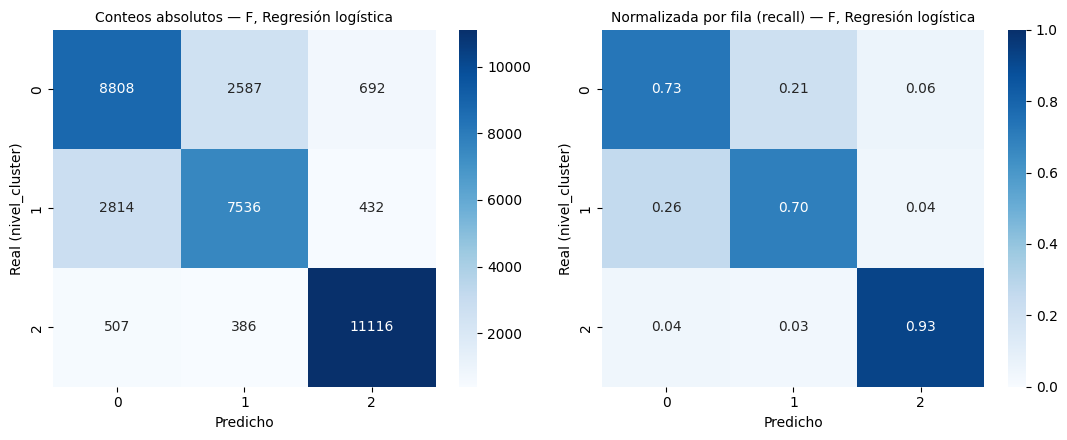

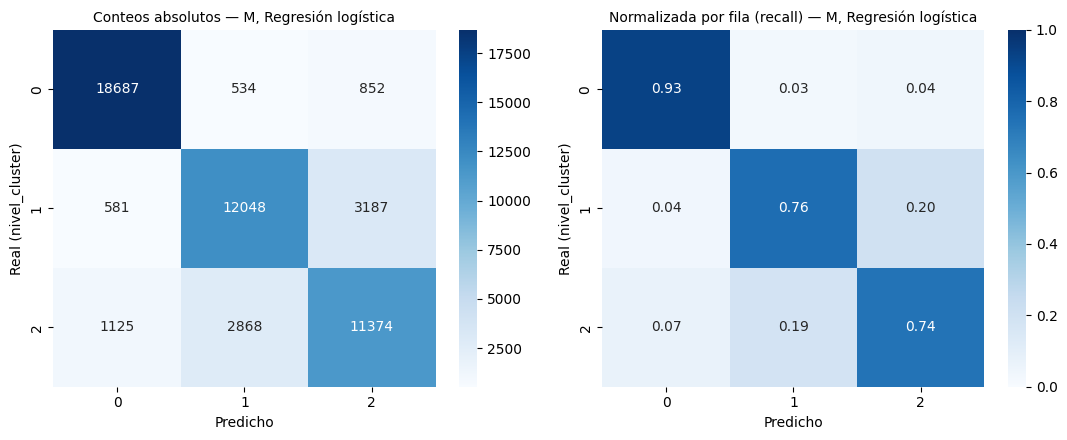

In [38]:
# ---------------------------------------------------------------------------
# 11. MATRIZ DE CONFUSIÓN — genérica
# ---------------------------------------------------------------------------
for genero in ["F", "M"]:
    sub_comp = comparacion_df[comparacion_df["genero"] == genero]
    nombre_modelo = sub_comp.iloc[0]["modelo"]
    estimador = modelos_entrenados[(genero, nombre_modelo)]

    X_test = resultados[genero]["X_test"]
    y_test = resultados[genero]["y_test"]
    pred_test = estimador.predict(X_test)

    cm = confusion_matrix(y_test, pred_test)
    cm_normalizada = confusion_matrix(y_test, pred_test, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
    axes[0].set_title(f"Conteos absolutos — {genero}, {nombre_modelo}", fontsize=10)
    axes[0].set_xlabel("Predicho")
    axes[0].set_ylabel("Real (nivel_cluster)")

    sns.heatmap(cm_normalizada, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
                xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()), vmin=0, vmax=1)
    axes[1].set_title(f"Normalizada por fila (recall) — {genero}, {nombre_modelo}", fontsize=10)
    axes[1].set_xlabel("Predicho")
    axes[1].set_ylabel("Real (nivel_cluster)")

    plt.tight_layout()
    plt.show()

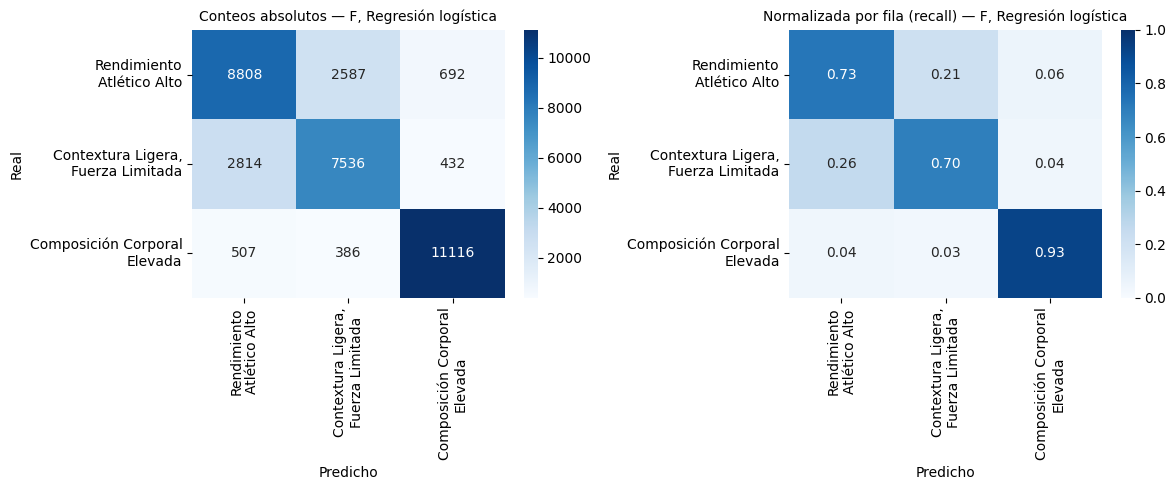

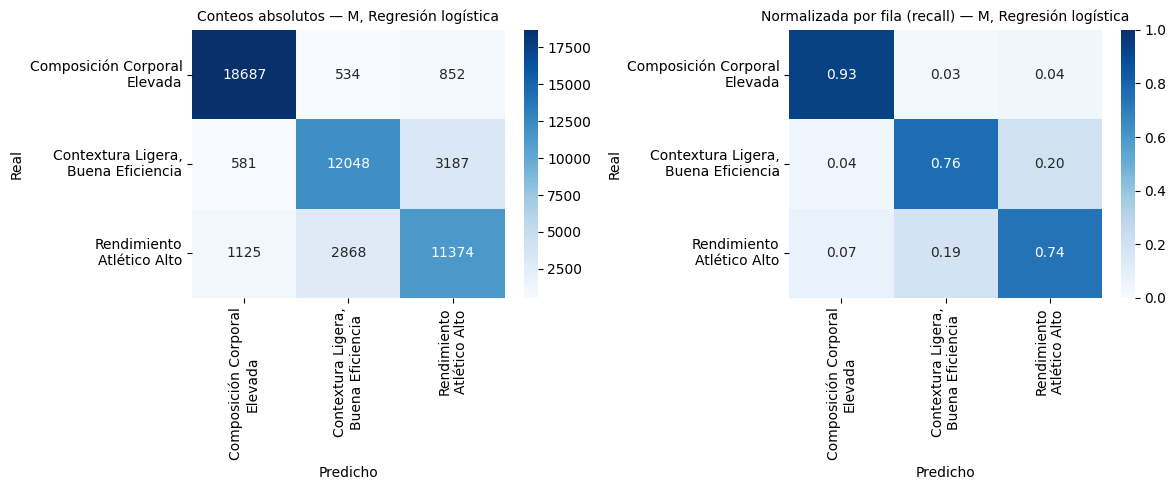

In [39]:
# ---------------------------------------------------------------------------
# 12. MATRIZ DE CONFUSIÓN — con nombres de cluster
# ---------------------------------------------------------------------------
NOMBRES_CLUSTER = {
    "F": {0: "Rendimiento\nAtlético Alto", 1: "Contextura Ligera,\nFuerza Limitada",
          2: "Composición Corporal\nElevada"},
    "M": {0: "Composición Corporal\nElevada", 1: "Contextura Ligera,\nBuena Eficiencia",
          2: "Rendimiento\nAtlético Alto"},
}

for genero in ["F", "M"]:
    sub_comp = comparacion_df[comparacion_df["genero"] == genero]
    nombre_modelo = sub_comp.iloc[0]["modelo"]
    estimador = modelos_entrenados[(genero, nombre_modelo)]

    X_test = resultados[genero]["X_test"]
    y_test = resultados[genero]["y_test"]
    pred_test = estimador.predict(X_test)

    clases_ordenadas = sorted(y_test.unique())
    etiquetas = [NOMBRES_CLUSTER[genero][c] for c in clases_ordenadas]

    cm = confusion_matrix(y_test, pred_test, labels=clases_ordenadas)
    cm_normalizada = confusion_matrix(y_test, pred_test, labels=clases_ordenadas, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=etiquetas, yticklabels=etiquetas)
    axes[0].set_title(f"Conteos absolutos — {genero}, {nombre_modelo}", fontsize=10)
    axes[0].set_xlabel("Predicho")
    axes[0].set_ylabel("Real")

    sns.heatmap(cm_normalizada, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
                xticklabels=etiquetas, yticklabels=etiquetas, vmin=0, vmax=1)
    axes[1].set_title(f"Normalizada por fila (recall) — {genero}, {nombre_modelo}", fontsize=10)
    axes[1].set_xlabel("Predicho")
    axes[1].set_ylabel("Real")

    plt.tight_layout()
    plt.show()